In [ ]:
import numpy as np
from pygimli.physics import ert
from fdip import FDIP
from matplotlib.colors import ListedColormap

In [42]:
p2 = FDIP("slagheap2.res")
print(p2)

17/08/26 - 19:27:27 - pyGIMLi - INFO - filtering: nd=590, nf=13
17/08/26 - 19:27:27 - pyGIMLi - INFO - Sum(ind): 590
17/08/26 - 19:27:27 - pyGIMLi - INFO - filtered: nd=590, nf=13


SIP data: nf=13 nc=49 nv=50 Data: Sensors: 33 data: 590, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']
SimulationMode = 0
PortNumber = 4
Shunt = 1.64
RRU_in_the_Lab = 0
RRU_Shunt = 0
RRU_K-Factor = 0
MinFrqInd = 13
MaxOutputVoltage = 250.0
MaxOutputCurrent_mA = 250.0
Number_of_Readings = 49
Readings = array((49, 30))
Number_of_Remote_Units = 32
RU-Configuration = array((32, 5))
Layout = array((33, 6))
Ref.-Layout = array((0,))
FrequencyParameter = array((21, 7))


In [43]:
xh = np.loadtxt("slagheap2.topo")
p2.setElectrodePositions(xh)

17/08/26 - 19:27:36 - pyGIMLi - INFO - Save RVector binary
17/08/26 - 19:27:36 - pyGIMLi - INFO - Cache stored: C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\304913579755130094


17/08/26 - 19:27:44 - pyGIMLi - INFO - filtering: nd=590, nf=13
17/08/26 - 19:27:44 - pyGIMLi - INFO - Sum(ind): 534
17/08/26 - 19:27:44 - pyGIMLi - INFO - filtered: nd=534, nf=13
17/08/26 - 19:27:44 - pyGIMLi - INFO - use frequency index: 0 for 0.312 Hz


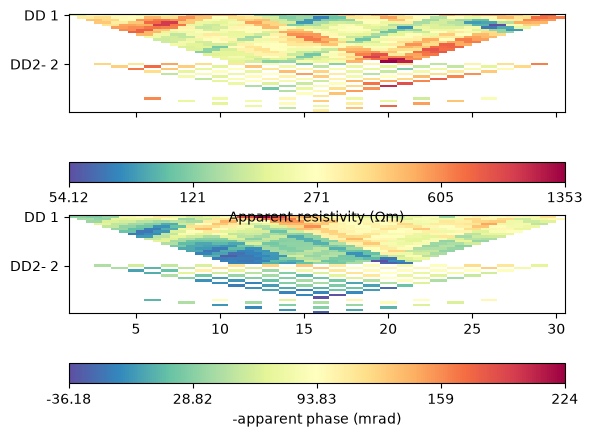

In [45]:
p2.filter(kmax=30000)
p2.showSingleFrequencyData(0.3);

In [46]:
# p2.generateDataPDF(ipmax=100)
# p2.generateSpectraPDF()

In [47]:
p2.basename += '_corr'

In [51]:
# p2.filter(fmax=21.)
# p2.generateSpectraPDF()
p2.generateDataPDF()

<Figure size 800x1000 with 0 Axes>

In [55]:
# data1 = p2.singleFrequencyData(1.25)
# mgr = ert.ERTIPManager(data1, fd=True)
# mgr.invert(zWeight=0.3)
# mgr.showResults()

In [56]:
p2.singleInversion(1.0, paraDepth=10, zWeight=0.3, verbose=True)

17/08/26 - 19:31:29 - pyGIMLi - INFO - Use median(data values)=258.065875
17/08/26 - 19:31:29 - pyGIMLi - INFO - Created startmodel from forward operator:829, min/max=258.065875/258.065875
17/08/26 - 19:31:29 - pyGIMLi - INFO - Starting inversion.
17/08/26 - 19:31:29 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002216BCDA390>
17/08/26 - 19:31:29 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
17/08/26 - 19:31:29 - pyGIMLi - INFO - Model transformation (cumulative):
17/08/26 - 19:31:29 - pyGIMLi - INFO - 	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
17/08/26 - 19:31:29 - pyGIMLi - INFO - min/max (data): 50.15/1377
17/08/26 - 19:31:29 - pyGIMLi - INFO - min/max (error): 3%/26.66%


17/08/26 - 19:31:29 - pyGIMLi - INFO - min/max (start model): 258/258
17/08/26 - 19:31:39 - pyGIMLi - INFO - inv.iter 0 ... chi² =  200.03


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

17/08/26 - 19:31:40 - pyGIMLi - INFO - chi² =   46.72 (dPhi = 76.36%) lam: 20.0
17/08/26 - 19:31:41 - pyGIMLi - INFO - chi² =    9.50 (dPhi = 77.81%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 2 ... --------------------------------------------------------------------------------
inv.iter 3 ... 

17/08/26 - 19:31:43 - pyGIMLi - INFO - chi² =    4.64 (dPhi = 45.40%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 4 ... 

17/08/26 - 19:31:45 - pyGIMLi - INFO - chi² =    4.54 (dPhi = 1.43%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 1.43 (< 2.0%)                 #
################################################################################
WARNING! found negative phases .. taking abs of ip data.


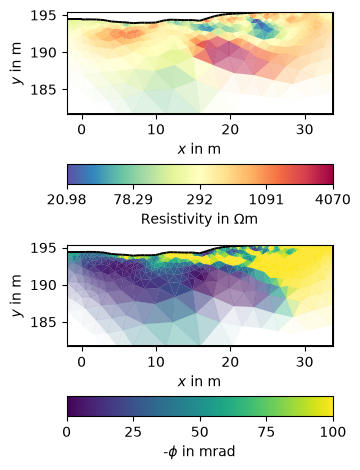

In [58]:
p2.showSingleResult(imax=100);

(185.0, 195.4)

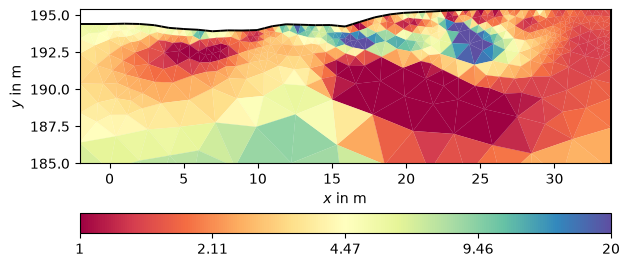

In [66]:
s1 = 1000/p2.res*np.cos(p2.phi)
ax, cb = p2.pd.show(s1, cMin=1, cMax=20, cMap="Spectral", logScale=True)
ax.set_ylim(185, 195.4)

(185.0, 195.4)

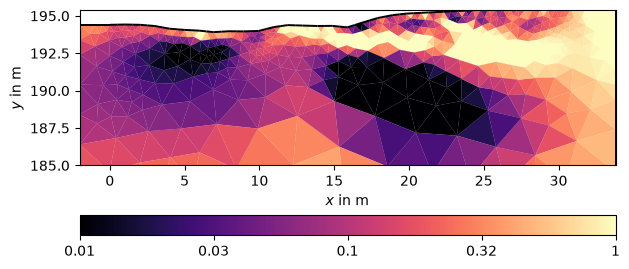

In [69]:
s2 = 1000/p2.res*np.sin(p2.phi)
ax, cb = p2.pd.show(s2, cMin=0.01, cMax=1, cMap="magma", logScale=True)
ax.set_ylim(185, 195.4)

In [70]:
p2.simultaneousInversion(verbose=True, zWeight=0.3)

17/08/26 - 19:37:17 - pyGIMLi - INFO - Found 2 regions.
17/08/26 - 19:37:17 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


17/08/26 - 19:37:17 - pyGIMLi - INFO - Creating forward mesh from region infos.
17/08/26 - 19:37:17 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
17/08/26 - 19:37:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3297 Cells: 6312 Boundaries: 4874
c:\src\ERT\FDIP\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
17/08/26 - 19:37:18 - pyGIMLi - INFO - Starting inversion.
17/08/26 - 19:37:18 - pyGIMLi - INFO - fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x0000022195E08C20>
17/08/26 - 19:37:18 - pyGIMLi - INFO - Data transformation: Identity transform
17/08/26 - 19:37:18 - pyGIMLi - INFO - Model transformation: Logarithmic transform
17/08/26 - 19:37:18 - pyGIMLi - INFO - min/max (data): 44.12/1391
17/08/26 - 19:37:18 - pyGIMLi - INFO - min/max (error): 3%/26.66%
17/08/26 - 19:37:18 - pyGIMLi - INFO - min

829 model cells
--------------------------------------------------------------------------------


17/08/26 - 19:38:38 - pyGIMLi - INFO - inv.iter 0 ... chi² =  277.55


--------------------------------------------------------------------------------
inv.iter 1 ... 

...

--------------------------------------------------------------------------------
inv.iter 8 ... --------------------------------------------------------------------------------
inv.iter 9 ... 

17/08/26 - 20:19:47 - pyGIMLi - INFO - chi² =    1.29 (dPhi = 3.25%) lam: 20.0
17/08/26 - 20:19:49 - pyGIMLi - INFO - chi² =    1.23 (dPhi = 2.21%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 10 ... --------------------------------------------------------------------------------
inv.iter 11 ... 

17/08/26 - 20:19:51 - pyGIMLi - INFO - chi² =    1.21 (dPhi = 0.26%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 0.26 (< 2.0%)                 #
################################################################################


In [71]:
p2.saveResults()

[0.312 0.625]
[1.25 2.5  5.  ]
[10. 20.]


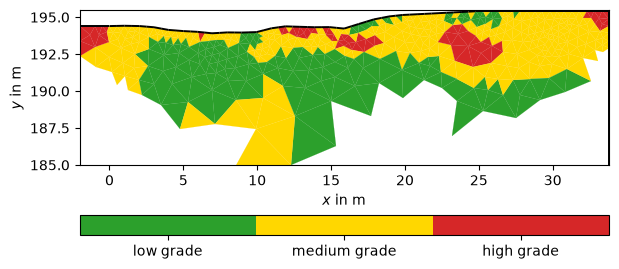

In [89]:
frange = [0.1, 1.0, 7.0, 100.0]
nfr = len(frange)-1
fres = np.zeros((len(p2.res), nfr))
fphi = np.zeros((len(p2.res), nfr))
for i in range(nfr):
    find = (p2.freq > frange[i]) & (p2.freq <= frange[i+1])
    print(p2.freq[find])
    fres[:, i] = np.mean(p2.RES[:, find], axis=1)
    fphi[:, i] = np.mean(p2.PHI[:, find], axis=1)

fs2s = 1. / fres * np.sin(fphi)
fs2sMF = fs2s[:, 1] * 1000
grade = (fs2sMF > 0.1) + 1.0
grade[fs2sMF > 1] = 3
cm = ListedColormap(["tab:green", "gold", "tab:red"])

ax, cb = p2.pd.show(grade, cMin=.5, cMax=3.5, cMap=cm,
                    xlabel="x [m]", ylabel="z [m]", coverage=(p2.coverage>-.25))
ax.set_ylim(185, 195.5)
cb.set_ticks([1, 2, 3])
cb.set_ticklabels(["low grade", "medium grade", "high grade"])


[2. 3.]


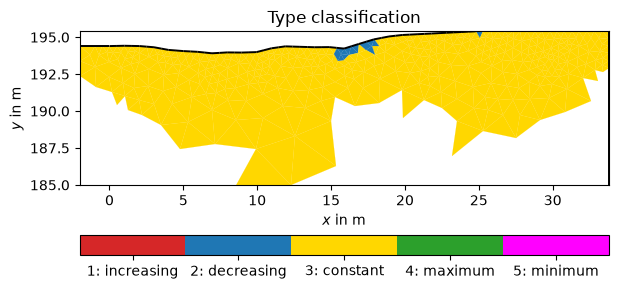

In [96]:
means = np.mean(fs2s, axis=1)
der1 = (fs2s[:, 1] - fs2s[:, 0]) / (fs2s[:, 1] + fs2s[:, 0]) * 2  #means
der2 = (fs2s[:, 2] - fs2s[:, 1]) / (fs2s[:, 2] + fs2s[:, 1]) * 2  # means
typ = np.ones(len(p2.res))*3.0
typ[(der1 > 0) & (der2 > 0)] = 1  # ansteigend
typ[(der1 < 0) & (der2 < 0)] = 2  # absteigend
typ[(der1 > 0) & (der2 < 0)] = 4  # an und dann ab (min-max-min)
typ[(der1 < 0) & (der2 > 0)] = 5  # ab und dann an (max-min-max) Badewanne
typ[np.sqrt(np.abs(der1*der2)) < 0.1] = 3  # konstant (<10%)
# typ = np.sign(der1 * der2) * (np.abs(np.sign(der1) - np.sign(der2)) + 1)
print(np.unique(typ))
co = (means > 3e-6) & (p2.coverage > -0.25)  # 0.1mS/m
cm = ListedColormap(["tab:red", "tab:blue", "gold", "tab:green", "magenta"])
labels = np.array(["1: increasing", "2: decreasing", "3: constant",
                   "4: maximum", "5: minimum"])
ax, cb = p2.pd.show(typ, coverage=co, cMin=.50, cMax=5.5, cMap=cm,
                    xlabel="x [m]", ylabel="z [m]")
# pg.viewer.mpl.drawMesh(ax, fdip.pd, color="lightgray")
ax.set_ylim(185, 195.4)
cb.set_ticks([1, 2, 3, 4, 5])
cb.set_ticklabels(labels)
ax.set_title("Type classification");

In [90]:
p2.fitAllRhoPhi();

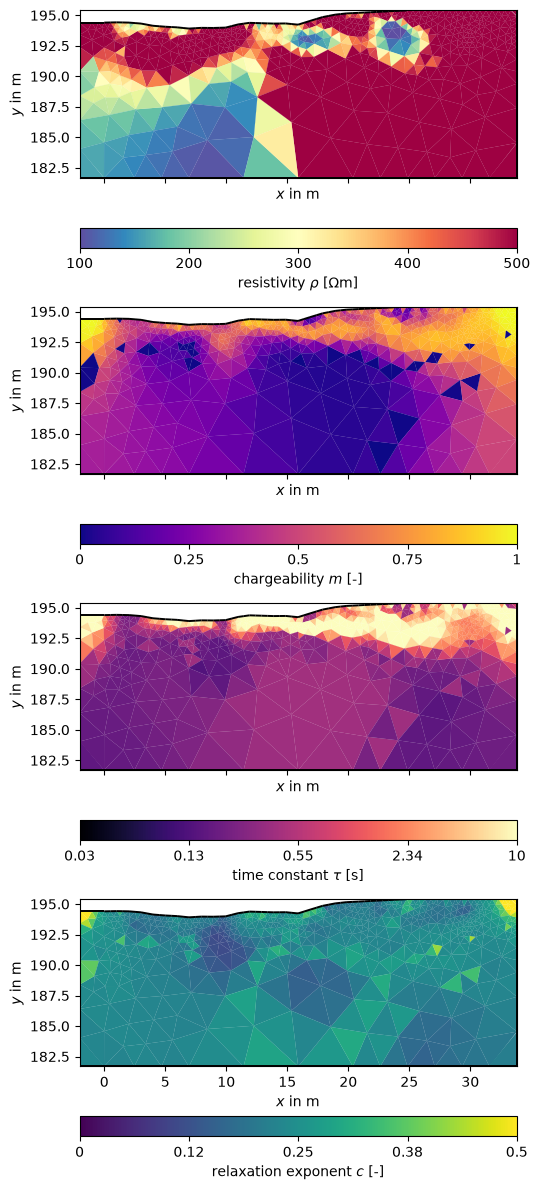

In [ ]:
ax = p2.showColeColeParameters(coverage=1, rlim=(100, 500),                           mlim=(0, 1), tlim=(0.03, 10));